# finrag: full experiment run

Thin runner for the complete pipeline. Each cell calls the same CLI entry
points documented in the README; all logic lives in the package and the
experiment scripts, so this notebook cannot drift from the reproducible path.
Every stage is cached and resumable, so re-running the notebook replays
finished work instead of recomputing it.

Requirements: a CUDA GPU, uv, and Ollama with the five models pulled
(scripts/setup_pod.sh does all of this on a fresh pod).

## 1. Environment check

In [1]:
!uv run python -c "import torch; print(torch.__version__, torch.cuda.is_available() and torch.cuda.get_device_name(0))"
!uv run pytest

2.13.0+cu130 NVIDIA A100-SXM4-80GB


.

.................

.........................................

.....         [100%]
64 passed in 6.33s


## 2. Corpus: download and extract

In [2]:
!uv run finrag download

[  1/84] 3M_2018_10K                                   cached
[  2/84] ACTIVISIONBLIZZARD_2019_10K                   cached
[  3/84] 3M_2022_10K                                   cached
[  4/84] ADOBE_2015_10K                                cached
[  5/84] ADOBE_2022_10K                                cached
[  6/84] AMAZON_2017_10K                               cached
[  7/84] ADOBE_2016_10K                                cached
[  8/84] AMAZON_2019_10K                               cached
[  9/84] 3M_2023Q2_10Q                                 cached
[ 10/84] ADOBE_2017_10K                                cached
[ 11/84] AMCOR_2022_8K_dated-2022-07-01                cached
[ 12/84] AES_2022_10K                                  cached
[ 13/84] AMCOR_2023_10K                                cached
[ 14/84] AMCOR_2023Q2_10Q                              cached
[ 15/84] AMCOR_2023Q4_EARNINGS                         cached
[ 16/84] AMD_2015_10K                                  cached
[ 17/84]

[ 48/84] COCACOLA_2022_10K                             cached
[ 49/84] JPMORGAN_2021Q1_10Q                           cached
[ 50/84] JPMORGAN_2022Q2_10Q                           cached
[ 51/84] KRAFTHEINZ_2019_10K                           cached
[ 52/84] LOCKHEEDMARTIN_2020_10K                       cached
[ 53/84] LOCKHEEDMARTIN_2021_10K                       cached
[ 54/84] JPMORGAN_2023Q2_10Q                           cached
[ 55/84] LOCKHEEDMARTIN_2022_10K                       cached
[ 56/84] JPMORGAN_2022_10K                             cached
[ 57/84] MGMRESORTS_2018_10K                           cached
[ 58/84] MGMRESORTS_2020_10K                           cached
[ 59/84] MGMRESORTS_2022Q4_EARNINGS                    cached
[ 60/84] MGMRESORTS_2022_10K                           cached
[ 61/84] MGMRESORTS_2023Q2_10Q                         cached
[ 62/84] MICROSOFT_2016_10K                            cached
[ 63/84] MICROSOFT_2023_10K                            cached
[ 64/84]

In [3]:
!uv run finrag extract

[  1/84] 3M_2018_10K                                    160 pages


[  2/84] 3M_2022_10K                                    252 pages


[  3/84] 3M_2023Q2_10Q                                   92 pages


[  4/84] ACTIVISIONBLIZZARD_2019_10K                    198 pages


[  5/84] ADOBE_2015_10K                                 116 pages


...

[ 81/84] VERIZON_2022_10K                               124 pages


[ 82/84] WALMART_2018_10K                               304 pages


[ 83/84] WALMART_2019_10K                               155 pages


[ 84/84] WALMART_2020_10K                               170 pages



12,013 pages, 39,968,834 characters from 84 documents -> /workspace/nlp-project-A/data/corpus/pages.jsonl


## 3. Retrieval grid (41 configurations, cached and resumable)

In [4]:
!uv run python experiments/run_grid.py --sweep all --device cuda

Grid: 41 configurations across sweeps ['chunking', 'structure', 'embeddings', 'k', 'strategy', 'filter']
Eval set: 150 answerable questions (0 excluded)


Device: cuda (NVIDIA A100-SXM4-80GB)

[ 1/41] chunk128/ov0%
  65,315 chunks | 12.2 ms/query | recall=0.307  strict_recall=0.053  doc_accuracy=0.780  mrr=0.214  ndcg=0.279  evidence_coverage=0.112

[ 2/41] chunk128/ov10%
  72,063 chunks | 12.8 ms/query | recall=0.360  strict_recall=0.093  doc_accuracy=0.813  mrr=0.225  ndcg=0.312  evidence_coverage=0.146

[ 3/41] chunk128/ov25%
  87,042 chunks | 14.5 ms/query | recall=0.320  strict_recall=0.080  doc_accuracy=0.820  mrr=0.203  ndcg=0.281  evidence_coverage=0.123

[ 4/41] chunk128/ov50%
  130,503 chunks | 20.8 ms/query | recall=0.327  strict_recall=0.067  doc_accuracy=0.800  mrr=0.211  ndcg=0.306  evidence_coverage=0.115

[ 5/41] chunk256/ov0%
  32,680 chunks | 6.8 ms/query | recall=0.327  strict_recall=0.147  doc_accuracy=0.787  mrr=0.195  ndcg=0.258  evidence_coverage=0.198

[ 6/41] chunk256/ov10%
  36,199 chunks | 7.9 ms/query | recall=0.373  strict_recall=0.147  doc_accuracy=0.787  mrr=0.226  ndcg=0.312  evidence_coverage=0.210

[ 7/4

  43,529 chunks | 8.4 ms/query | recall=0.313  strict_recall=0.160  doc_accuracy=0.793  mrr=0.210  ndcg=0.284  evidence_coverage=0.191

[ 8/41] chunk256/ov50%
  65,231 chunks | 11.7 ms/query | recall=0.347  strict_recall=0.173  doc_accuracy=0.800  mrr=0.250  ndcg=0.340  evidence_coverage=0.218

[ 9/41] chunk512/ov0%
  16,363 chunks | 5.6 ms/query | recall=0.307  strict_recall=0.213  doc_accuracy=0.807  mrr=0.173  ndcg=0.201  evidence_coverage=0.223

[10/41] chunk512/ov10%
  18,156 chunks | 5.9 ms/query | recall=0.367  strict_recall=0.233  doc_accuracy=0.827  mrr=0.203  ndcg=0.249  evidence_coverage=0.248

[11/41] chunk512/ov25%
  21,773 chunks | 6.2 ms/query | recall=0.320  strict_recall=0.213  doc_accuracy=0.800  mrr=0.217  ndcg=0.275  evidence_coverage=0.226

[12/41] chunk512/ov50%
  32,596 chunks | 8.6 ms/query | recall=0.300  strict_recall=0.227  doc_accuracy=0.827  mrr=0.178  ndcg=0.240  evidence_coverage=0.218

[13/41] chunk1024/ov0%
  8,199 chunks | 7.2 ms/query | recall=0.307  

  18,676 chunks | 5.7 ms/query | recall=0.333  strict_recall=0.240  doc_accuracy=0.827  mrr=0.177  ndcg=0.228  evidence_coverage=0.235

[18/41] struct:page
  23,133 chunks | 6.2 ms/query | recall=0.367  strict_recall=0.320  doc_accuracy=0.833  mrr=0.220  ndcg=0.241  evidence_coverage=0.292

[19/41] struct:structural
  22,752 chunks | 6.2 ms/query | recall=0.347  strict_recall=0.280  doc_accuracy=0.827  mrr=0.223  ndcg=0.241  evidence_coverage=0.271

[20/41] embed:all-MiniLM-L6-v2
  18,676 chunks | 4.5 ms/query | recall=0.253  strict_recall=0.173  doc_accuracy=0.687  mrr=0.144  ndcg=0.181  evidence_coverage=0.181

[21/41] embed:gte-base
  18,676 chunks | 6.0 ms/query | recall=0.313  strict_recall=0.253  doc_accuracy=0.820  mrr=0.169  ndcg=0.219  evidence_coverage=0.244

[22/41] embed:e5-base-v2
  18,676 chunks | 5.8 ms/query | recall=0.387  strict_recall=0.273  doc_accuracy=0.927  mrr=0.237  ndcg=0.283  evidence_coverage=0.278

[23/41] embed:e5-large-v2
  18,676 chunks | 6.7 ms/query | 

  18,676 chunks | 8.4 ms/query | recall=0.500  strict_recall=0.333  doc_accuracy=0.947  mrr=0.198  ndcg=0.303  evidence_coverage=0.330

[28/41] k=20
  18,676 chunks | 12.8 ms/query | recall=0.587  strict_recall=0.427  doc_accuracy=0.980  mrr=0.204  ndcg=0.352  evidence_coverage=0.413

[29/41] bm25@k=5
  18,676 chunks | 224.3 ms/query | recall=0.120  strict_recall=0.107  doc_accuracy=0.527  mrr=0.092  ndcg=0.124  evidence_coverage=0.106

[30/41] bm25@k=10
  18,676 chunks | 228.7 ms/query | recall=0.153  strict_recall=0.127  doc_accuracy=0.713  mrr=0.096  ndcg=0.138  evidence_coverage=0.134

[31/41] hybrid:a=0.3@k=10
  18,676 chunks | 339.4 ms/query | recall=0.227  strict_recall=0.173  doc_accuracy=0.800  mrr=0.117  ndcg=0.175  evidence_coverage=0.175

[32/41] hybrid:a=0.5@k=10
  18,676 chunks | 340.0 ms/query | recall=0.253  strict_recall=0.187  doc_accuracy=0.853  mrr=0.139  ndcg=0.203  evidence_coverage=0.197

[33/41] hybrid:a=0.7@k=10
  18,676 chunks | 340.9 ms/query | recall=0.320  

  18,676 chunks | 243.9 ms/query | recall=0.493  strict_recall=0.400  doc_accuracy=0.947  mrr=0.199  ndcg=0.321  evidence_coverage=0.391

[38/41] filter@k=5
  18,676 chunks | 25.4 ms/query | recall=0.493  strict_recall=0.300  doc_accuracy=0.920  mrr=0.284  ndcg=0.392  evidence_coverage=0.294

[39/41] filter@k=10
  18,676 chunks | 36.7 ms/query | recall=0.627  strict_recall=0.407  doc_accuracy=0.980  mrr=0.301  ndcg=0.471  evidence_coverage=0.395

[40/41] filter@k=20
  18,676 chunks | 56.7 ms/query | recall=0.707  strict_recall=0.507  doc_accuracy=0.987  mrr=0.307  ndcg=0.533  evidence_coverage=0.489

[41/41] filter+rerank:pool=100@k=10
  18,676 chunks | 239.8 ms/query | recall=0.547  strict_recall=0.393  doc_accuracy=0.973  mrr=0.290  ndcg=0.419  evidence_coverage=0.398



In [5]:
!uv run python experiments/analyze_retrieval.py

Analysing 41 retrieval runs


  retrieval_results.md / .csv (41 rows)


  fig_chunking.png


  fig_structure.png


  fig_embeddings.png


  fig_k.png


  fig_strategy.png


  fig_strategy_by_type.png


  error_analysis.md


## 4. Generation sweep (five models), ablations, and analysis

In [6]:
!uv run python experiments/run_generation.py --all -k 10

Retrieval run: filter@k=20 (recall@20 = 0.707)

retrieved:llama3.1:8b-instruct-q4_K_M


Resuming: 150 questions already generated.

retrieved:llama3.1:8b-instruct-q4_K_M  [llama3.1:8b-instruct-q4_K_M, context=retrieved, k=10]
{
  "n_questions": 150,
  "abstention_rate": 0.46,
  "citation_rate": 0.66,
  "citation_valid_rate": 0.32666666666666666,
  "numeric_accuracy": 0.23015873015873015,
  "numeric_accuracy_scale_tolerant": 0.2777777777777778,
  "token_f1": 0.0760115762526083,
  "mean_seconds_per_question": 3.4195215543111166,
  "n_truncation_suspected": 0,
  "judge:ollama:qwen2.5:14b-instruct-q4_K_M": {
    "n_judged": 150,
    "mean_correctness": 0.5,
    "fully_correct_rate": 0.2,
    "partially_correct_rate": 0.1,
    "mean_groundedness": 1.3666666666666667,
    "fully_grounded_rate": 0.54,
    "hallucination_rate": 0.44666666666666666,
    "citations_supported_rate": 0.7533333333333333
  }
}

retrieved:mistral:7b-instruct


Resuming: 150 questions already generated.



retrieved:mistral:7b-instruct  [mistral:7b-instruct, context=retrieved, k=10]
{
  "n_questions": 150,
  "abstention_rate": 0.5066666666666667,
  "citation_rate": 0.4666666666666667,
  "citation_valid_rate": 0.17333333333333334,
  "numeric_accuracy": 0.16666666666666666,
  "numeric_accuracy_scale_tolerant": 0.2222222222222222,
  "token_f1": 0.14388603126191177,
  "mean_seconds_per_question": 2.8073902304967246,
  "n_truncation_suspected": 0,
  "judge:ollama:qwen2.5:14b-instruct-q4_K_M": {
    "n_judged": 150,
    "mean_correctness": 0.6066666666666667,
    "fully_correct_rate": 0.25333333333333335,
    "partially_correct_rate": 0.1,
    "mean_groundedness": 1.42,
    "fully_grounded_rate": 0.5866666666666667,
    "hallucination_rate": 0.3333333333333333,
    "citations_supported_rate": 0.7866666666666666
  }
}

retrieved:qwen2.5:7b-instruct


Resuming: 150 questions already generated.



retrieved:qwen2.5:7b-instruct  [qwen2.5:7b-instruct, context=retrieved, k=10]
{
  "n_questions": 150,
  "abstention_rate": 0.5533333333333333,
  "citation_rate": 0.4266666666666667,
  "citation_valid_rate": 0.21333333333333335,
  "numeric_accuracy": 0.19047619047619047,
  "numeric_accuracy_scale_tolerant": 0.2619047619047619,
  "token_f1": 0.11902471041898038,
  "mean_seconds_per_question": 2.3260103432337442,
  "n_truncation_suspected": 0,
  "judge:ollama:qwen2.5:14b-instruct-q4_K_M": {
    "n_judged": 150,
    "mean_correctness": 0.58,
    "fully_correct_rate": 0.24666666666666667,
    "partially_correct_rate": 0.08666666666666667,
    "mean_groundedness": 1.6266666666666667,
    "fully_grounded_rate": 0.7466666666666667,
    "hallucination_rate": 0.31333333333333335,
    "citations_supported_rate": 0.8933333333333333
  }
}

retrieved:phi4:14b


Resuming: 150 questions already generated.

retrieved:phi4:14b  [phi4:14b, context=retrieved, k=10]
{
  "n_questions": 150,
  "abstention_rate": 0.49333333333333335,
  "citation_rate": 0.66,
  "citation_valid_rate": 0.31333333333333335,
  "numeric_accuracy": 0.30158730158730157,
  "numeric_accuracy_scale_tolerant": 0.38095238095238093,
  "token_f1": 0.11100215522384889,
  "mean_seconds_per_question": 5.236617692311605,
  "n_truncation_suspected": 0,
  "judge:ollama:qwen2.5:14b-instruct-q4_K_M": {
    "n_judged": 150,
    "mean_correctness": 0.8733333333333333,
    "fully_correct_rate": 0.36666666666666664,
    "partially_correct_rate": 0.14,
    "mean_groundedness": 1.5333333333333334,
    "fully_grounded_rate": 0.66,
    "hallucination_rate": 0.28,
    "citations_supported_rate": 0.8666666666666667
  }
}

retrieved:qwen2.5:14b-instruct-q4_K_M


Resuming: 150 questions already generated.

retrieved:qwen2.5:14b-instruct-q4_K_M  [qwen2.5:14b-instruct-q4_K_M, context=retrieved, k=10]
{
  "n_questions": 150,
  "abstention_rate": 0.36,
  "citation_rate": 0.6533333333333333,
  "citation_valid_rate": 0.34,
  "numeric_accuracy": 0.29365079365079366,
  "numeric_accuracy_scale_tolerant": 0.38095238095238093,
  "token_f1": 0.13888405988659983,
  "mean_seconds_per_question": 12.294542589187621,
  "n_truncation_suspected": 0,
  "judge:ollama:qwen2.5:14b-instruct-q4_K_M": {
    "n_judged": 150,
    "mean_correctness": 0.82,
    "fully_correct_rate": 0.36666666666666664,
    "partially_correct_rate": 0.08666666666666667,
    "mean_groundedness": 1.5866666666666667,
    "fully_grounded_rate": 0.7333333333333333,
    "hallucination_rate": 0.2733333333333333,
    "citations_supported_rate": 0.8533333333333334
  }
}


In [7]:
!uv run python experiments/run_generation.py --gen-model qwen2.5:14b-instruct-q4_K_M --context-mode oracle --name oracle:qwen14b
!uv run python experiments/run_generation.py --gen-model qwen2.5:7b-instruct --context-mode oracle --name oracle:qwen7b
!uv run python experiments/run_generation.py --gen-model qwen2.5:14b-instruct-q4_K_M --context-mode none --judge none --name closedbook:qwen14b
!uv run python experiments/run_generation.py --gen-model qwen2.5:7b-instruct --context-mode none --judge none --name closedbook:qwen7b
!uv run python experiments/run_generation.py --gen-model qwen2.5:14b-instruct-q4_K_M -k 20 --name k20:qwen2.5:14b


oracle:qwen14b
Resuming: 150 questions already generated.



oracle:qwen14b  [qwen2.5:14b-instruct-q4_K_M, context=oracle, k=5]
{
  "n_questions": 150,
  "abstention_rate": 0.12666666666666668,
  "citation_rate": 0.94,
  "citation_valid_rate": 0.94,
  "numeric_accuracy": 0.4523809523809524,
  "numeric_accuracy_scale_tolerant": 0.626984126984127,
  "token_f1": 0.19614278471460414,
  "mean_seconds_per_question": 3.212883752187093,
  "n_truncation_suspected": 0,
  "judge:ollama:qwen2.5:14b-instruct-q4_K_M": {
    "n_judged": 150,
    "mean_correctness": 1.3666666666666667,
    "fully_correct_rate": 0.5933333333333334,
    "partially_correct_rate": 0.18,
    "mean_groundedness": 1.72,
    "fully_grounded_rate": 0.82,
    "hallucination_rate": 0.2,
    "citations_supported_rate": 0.94
  }
}



oracle:qwen7b
Resuming: 150 questions already generated.



oracle:qwen7b  [qwen2.5:7b-instruct, context=oracle, k=5]
{
  "n_questions": 150,
  "abstention_rate": 0.34,
  "citation_rate": 0.6333333333333333,
  "citation_valid_rate": 0.6333333333333333,
  "numeric_accuracy": 0.29365079365079366,
  "numeric_accuracy_scale_tolerant": 0.4365079365079365,
  "token_f1": 0.15207720160265553,
  "mean_seconds_per_question": 2.685090840657552,
  "n_truncation_suspected": 0,
  "judge:ollama:qwen2.5:14b-instruct-q4_K_M": {
    "n_judged": 150,
    "mean_correctness": 0.9866666666666667,
    "fully_correct_rate": 0.4266666666666667,
    "partially_correct_rate": 0.13333333333333333,
    "mean_groundedness": 1.4666666666666666,
    "fully_grounded_rate": 0.6933333333333334,
    "hallucination_rate": 0.32,
    "citations_supported_rate": 0.8733333333333333
  }
}



closedbook:qwen14b
Resuming: 150 questions already generated.

closedbook:qwen14b  [qwen2.5:14b-instruct-q4_K_M, context=none, k=0]
{
  "n_questions": 150,
  "abstention_rate": 0.0,
  "citation_rate": 0.0,
  "citation_valid_rate": 0.0,
  "numeric_accuracy": 0.0873015873015873,
  "numeric_accuracy_scale_tolerant": 0.1111111111111111,
  "token_f1": 0.13755603728701224,
  "mean_seconds_per_question": 12.537614844640096,
  "n_truncation_suspected": 0
}



closedbook:qwen7b
Resuming: 150 questions already generated.

closedbook:qwen7b  [qwen2.5:7b-instruct, context=none, k=0]
{
  "n_questions": 150,
  "abstention_rate": 0.0,
  "citation_rate": 0.0,
  "citation_valid_rate": 0.0,
  "numeric_accuracy": 0.0873015873015873,
  "numeric_accuracy_scale_tolerant": 0.0873015873015873,
  "token_f1": 0.14875792505668373,
  "mean_seconds_per_question": 1.993716770807902,
  "n_truncation_suspected": 0
}


Retrieval run: filter@k=20 (recall@20 = 0.707)

k20:qwen2.5:14b


Resuming: 150 questions already generated.



k20:qwen2.5:14b  [qwen2.5:14b-instruct-q4_K_M, context=retrieved, k=20]
{
  "n_questions": 150,
  "abstention_rate": 0.19333333333333333,
  "citation_rate": 0.6,
  "citation_valid_rate": 0.26666666666666666,
  "numeric_accuracy": 0.31746031746031744,
  "numeric_accuracy_scale_tolerant": 0.42063492063492064,
  "token_f1": 0.13691561947936998,
  "mean_seconds_per_question": 17.61834988117218,
  "n_truncation_suspected": 0,
  "judge:ollama:qwen2.5:14b-instruct-q4_K_M": {
    "n_judged": 150,
    "mean_correctness": 0.9333333333333333,
    "fully_correct_rate": 0.38666666666666666,
    "partially_correct_rate": 0.16,
    "mean_groundedness": 1.5133333333333334,
    "fully_grounded_rate": 0.6333333333333333,
    "hallucination_rate": 0.28,
    "citations_supported_rate": 0.8266666666666667
  }
}


In [8]:
!uv run python experiments/analyze_generation.py

Analysing 10 generation runs


  generation_results.md / .csv (10 rows)


  fig_gen_models.png


  fig_context_modes.png


  fig_by_reasoning.png
  retrieval_vs_generation.md


## 5. Judge consistency check

The LLM judge is validated against the deterministic scale-tolerant numeric
metric over every judged answer to a numeric question.

In [9]:
import sys, json, glob
sys.path.insert(0, 'src')
from finrag.judge import cohen_kappa

pairs = []
for p in glob.glob('results/generations/*.json'):
    d = json.load(open(p))
    if d['config']['context_mode'] == 'none':
        continue
    for g in d['generations']:
        v = next(iter(g.get('verdicts', {}).values()), None)
        num = g['scores']['numeric_correct_scale_tolerant']
        if v and 'correctness' in v and num is not None:
            pairs.append((1 if v['correctness'] == 2 else 0, 1 if num else 0))
a = [x for x, _ in pairs]; b = [y for _, y in pairs]
print(f'n={len(pairs)} | agreement={sum(x==y for x,y in pairs)/len(pairs):.3f} | kappa={cohen_kappa(a,b):.3f}')

n=1008 | agreement=0.816 | kappa=0.607


## 6. Results: tables and figures

# Retrieval results (all configurations, sorted by recall)

| label                       | strategy   | chunking          | embedding         |   k | filter   |   recall |   strict_recall |   doc_accuracy |   mrr |   ndcg |   evidence_coverage |   ms_per_query |
|:----------------------------|:-----------|:------------------|:------------------|----:|:---------|---------:|----------------:|---------------:|------:|-------:|--------------------:|---------------:|
| filter@k=20                 | dense      | token 512/64      | bge-base-en-v1.5  |  20 | yes      |    0.707 |           0.507 |          0.987 | 0.307 |  0.533 |               0.489 |         56.700 |
| filter@k=10                 | dense      | token 512/64      | bge-base-en-v1.5  |  10 | yes      |    0.627 |           0.407 |          0.980 | 0.301 |  0.471 |               0.395 |         36.700 |
| k=20                        | dense      | token 512/64      | bge-base-en-v1.5  |  20 |          |    0.587 |           0.427 |          0.980 | 0.204 |  0.352 |               0.413 |         12.800 |
| filter+rerank:pool=100@k=10 | rerank     | token 512/64      | bge-base-en-v1.5  |  10 | yes      |    0.547 |           0.393 |          0.973 | 0.290 |  0.419 |               0.398 |        239.800 |
| k=10                        | dense      | token 512/64      | bge-base-en-v1.5  |  10 |          |    0.500 |           0.333 |          0.947 | 0.198 |  0.303 |               0.330 |          8.400 |
| filter@k=5                  | dense      | token 512/64      | bge-base-en-v1.5  |   5 | yes      |    0.493 |           0.300 |          0.920 | 0.284 |  0.392 |               0.294 |         25.400 |
| rerank:pool=100@k=20        | rerank     | token 512/64      | bge-base-en-v1.5  |  20 |          |    0.493 |           0.400 |          0.947 | 0.199 |  0.321 |               0.391 |        243.900 |
| embed:e5-large-v2           | dense      | token 512/64      | e5-large-v2       |   5 |          |    0.453 |           0.327 |          0.940 | 0.316 |  0.385 |               0.332 |          6.700 |
| rerank:pool=20@k=10         | rerank     | token 512/64      | bge-base-en-v1.5  |  10 |          |    0.447 |           0.340 |          0.913 | 0.203 |  0.292 |               0.327 |        178.100 |
| rerank:pool=50@k=10         | rerank     | token 512/64      | bge-base-en-v1.5  |  10 |          |    0.420 |           0.327 |          0.880 | 0.208 |  0.290 |               0.320 |        221.400 |
| embed:bge-large-en-v1.5     | dense      | token 512/64      | bge-large-en-v1.5 |   5 |          |    0.413 |           0.307 |          0.873 | 0.246 |  0.298 |               0.287 |          6.500 |
| embed:e5-base-v2            | dense      | token 512/64      | e5-base-v2        |   5 |          |    0.387 |           0.273 |          0.927 | 0.237 |  0.283 |               0.278 |          5.800 |
| rerank:pool=100@k=10        | rerank     | token 512/64      | bge-base-en-v1.5  |  10 |          |    0.380 |           0.333 |          0.893 | 0.191 |  0.268 |               0.318 |        228.400 |
| chunk256/ov10%              | dense      | token 256/25      | bge-base-en-v1.5  |   5 |          |    0.373 |           0.147 |          0.787 | 0.226 |  0.312 |               0.210 |          7.900 |
| struct:page                 | dense      | page 512/64       | bge-base-en-v1.5  |   5 |          |    0.367 |           0.320 |          0.833 | 0.220 |  0.241 |               0.292 |          6.200 |
| chunk512/ov10%              | dense      | token 512/51      | bge-base-en-v1.5  |   5 |          |    0.367 |           0.233 |          0.827 | 0.203 |  0.249 |               0.248 |          5.900 |
| chunk128/ov10%              | dense      | token 128/12      | bge-base-en-v1.5  |   5 |          |    0.360 |           0.093 |          0.813 | 0.225 |  0.312 |               0.146 |         12.800 |
| chunk1024/ov10%             | dense      | token 1024/102    | bge-base-en-v1.5  |   5 |          |    0.353 |           0.247 |          0.833 | 0.207 |  0.239 |               0.259 |          7.400 |
| struct:structural           | dense      | structural 512/64 | bge-base-en-v1.5  |   5 |          |    0.347 |           0.280 |          0.827 | 0.223 |  0.241 |               0.271 |          6.200 |
| chunk256/ov50%              | dense      | token 256/128     | bge-base-en-v1.5  |   5 |          |    0.347 |           0.173 |          0.800 | 0.250 |  0.340 |               0.218 |         11.700 |
| struct:token                | dense      | token 512/64      | bge-base-en-v1.5  |   5 |          |    0.333 |           0.240 |          0.827 | 0.177 |  0.228 |               0.235 |          5.700 |
| chunk256/ov0%               | dense      | token 256/0       | bge-base-en-v1.5  |   5 |          |    0.327 |           0.147 |          0.787 | 0.195 |  0.258 |               0.198 |          6.800 |
| chunk128/ov50%              | dense      | token 128/64      | bge-base-en-v1.5  |   5 |          |    0.327 |           0.067 |          0.800 | 0.211 |  0.306 |               0.115 |         20.800 |
| hybrid:a=0.7@k=10           | hybrid     | token 512/64      | bge-base-en-v1.5  |  10 |          |    0.320 |           0.233 |          0.880 | 0.152 |  0.225 |               0.240 |        340.900 |
| chunk1024/ov50%             | dense      | token 1024/512    | bge-base-en-v1.5  |   5 |          |    0.320 |           0.260 |          0.800 | 0.184 |  0.219 |               0.261 |          8.800 |
| chunk512/ov25%              | dense      | token 512/128     | bge-base-en-v1.5  |   5 |          |    0.320 |           0.213 |          0.800 | 0.217 |  0.275 |               0.226 |          6.200 |
| chunk128/ov25%              | dense      | token 128/32      | bge-base-en-v1.5  |   5 |          |    0.320 |           0.080 |          0.820 | 0.203 |  0.281 |               0.123 |         14.500 |
| embed:gte-base              | dense      | token 512/64      | gte-base          |   5 |          |    0.313 |           0.253 |          0.820 | 0.169 |  0.219 |               0.244 |          6.000 |
| chunk256/ov25%              | dense      | token 256/64      | bge-base-en-v1.5  |   5 |          |    0.313 |           0.160 |          0.793 | 0.210 |  0.284 |               0.191 |          8.400 |
| chunk1024/ov0%              | dense      | token 1024/0      | bge-base-en-v1.5  |   5 |          |    0.307 |           0.247 |          0.853 | 0.181 |  0.199 |               0.257 |          7.200 |
| chunk512/ov0%               | dense      | token 512/0       | bge-base-en-v1.5  |   5 |          |    0.307 |           0.213 |          0.807 | 0.173 |  0.201 |               0.223 |          5.600 |
| chunk128/ov0%               | dense      | token 128/0       | bge-base-en-v1.5  |   5 |          |    0.307 |           0.053 |          0.780 | 0.214 |  0.279 |               0.112 |         12.200 |
| chunk512/ov50%              | dense      | token 512/256     | bge-base-en-v1.5  |   5 |          |    0.300 |           0.227 |          0.827 | 0.178 |  0.240 |               0.218 |          8.600 |
| chunk1024/ov25%             | dense      | token 1024/256    | bge-base-en-v1.5  |   5 |          |    0.293 |           0.260 |          0.800 | 0.191 |  0.219 |               0.262 |          7.900 |
| hybrid:a=0.5@k=10           | hybrid     | token 512/64      | bge-base-en-v1.5  |  10 |          |    0.253 |           0.187 |          0.853 | 0.139 |  0.203 |               0.197 |        340.000 |
| embed:all-MiniLM-L6-v2      | dense      | token 512/64      | all-MiniLM-L6-v2  |   5 |          |    0.253 |           0.173 |          0.687 | 0.144 |  0.181 |               0.181 |          4.500 |
| k=3                         | dense      | token 512/64      | bge-base-en-v1.5  |   3 |          |    0.240 |           0.173 |          0.727 | 0.156 |  0.185 |               0.185 |          4.800 |
| hybrid:a=0.3@k=10           | hybrid     | token 512/64      | bge-base-en-v1.5  |  10 |          |    0.227 |           0.173 |          0.800 | 0.117 |  0.175 |               0.175 |        339.400 |
| bm25@k=10                   | bm25       | token 512/64      | bge-base-en-v1.5  |  10 |          |    0.153 |           0.127 |          0.713 | 0.096 |  0.138 |               0.134 |        228.700 |
| bm25@k=5                    | bm25       | token 512/64      | bge-base-en-v1.5  |   5 |          |    0.120 |           0.107 |          0.527 | 0.092 |  0.124 |               0.106 |        224.300 |
| k=1                         | dense      | token 512/64      | bge-base-en-v1.5  |   1 |          |    0.093 |           0.093 |          0.440 | 0.093 |  0.093 |               0.093 |          3.800 |

# Generation results (sorted by judged accuracy)

| label                                 | model                       | context   |   k |   accuracy |   mean_correctness |   numeric |   numeric_scale_tol |   token_f1 |   abstain |   cited |   cite_valid |   grounded |   halluc |   s_per_q |   truncations |
|:--------------------------------------|:----------------------------|:----------|----:|-----------:|-------------------:|----------:|--------------------:|-----------:|----------:|--------:|-------------:|-----------:|---------:|----------:|--------------:|
| oracle:qwen14b                        | qwen2.5:14b-instruct-q4_K_M | oracle    |   5 |      0.593 |              1.367 |     0.452 |               0.627 |      0.196 |     0.127 |   0.940 |        0.940 |      1.720 |    0.200 |     3.213 |             0 |
| oracle:qwen7b                         | qwen2.5:7b-instruct         | oracle    |   5 |      0.427 |              0.987 |     0.294 |               0.437 |      0.152 |     0.340 |   0.633 |        0.633 |      1.467 |    0.320 |     2.685 |             0 |
| k20:qwen2.5:14b                       | qwen2.5:14b-instruct-q4_K_M | retrieved |  20 |      0.387 |              0.933 |     0.317 |               0.421 |      0.137 |     0.193 |   0.600 |        0.267 |      1.513 |    0.280 |    17.618 |             0 |
| retrieved:phi4:14b                    | phi4:14b                    | retrieved |  10 |      0.367 |              0.873 |     0.302 |               0.381 |      0.111 |     0.493 |   0.660 |        0.313 |      1.533 |    0.280 |     5.237 |             0 |
| retrieved:qwen2.5:14b-instruct-q4_K_M | qwen2.5:14b-instruct-q4_K_M | retrieved |  10 |      0.367 |              0.820 |     0.294 |               0.381 |      0.139 |     0.360 |   0.653 |        0.340 |      1.587 |    0.273 |    12.295 |             0 |
| retrieved:mistral:7b-instruct         | mistral:7b-instruct         | retrieved |  10 |      0.253 |              0.607 |     0.167 |               0.222 |      0.144 |     0.507 |   0.467 |        0.173 |      1.420 |    0.333 |     2.807 |             0 |
| retrieved:qwen2.5:7b-instruct         | qwen2.5:7b-instruct         | retrieved |  10 |      0.247 |              0.580 |     0.190 |               0.262 |      0.119 |     0.553 |   0.427 |        0.213 |      1.627 |    0.313 |     2.326 |             0 |
| retrieved:llama3.1:8b-instruct-q4_K_M | llama3.1:8b-instruct-q4_K_M | retrieved |  10 |      0.200 |              0.500 |     0.230 |               0.278 |      0.076 |     0.460 |   0.660 |        0.327 |      1.367 |    0.447 |     3.420 |             0 |
| closedbook:qwen7b                     | qwen2.5:7b-instruct         | none      |   0 |    nan     |            nan     |     0.087 |               0.087 |      0.149 |     0.000 |   0.000 |        0.000 |    nan     |  nan     |     1.994 |             0 |
| closedbook:qwen14b                    | qwen2.5:14b-instruct-q4_K_M | none      |   0 |    nan     |            nan     |     0.087 |               0.111 |      0.138 |     0.000 |   0.000 |        0.000 |    nan     |  nan     |    12.538 |             0 |

# Retrieval Error Analysis

Best configuration with k <= 10: **filter@k=10** (recall@10 = 0.627 over 150 questions)

## Failure taxonomy

| Failure mode | Count | Share of questions |
|---|---|---|
| Wrong document retrieved | 3 | 2.0% |
| Right document, wrong page | 53 | 35.3% |
| Gold page hit but evidence text mostly absent | 19 | 12.7% |
| **Total misses at k=10** | **56** | 37.3% |

Wrong-document failures are discrimination errors (company, year, or filing
type not pinned down) and respond to metadata filtering. Right-document
wrong-page failures are ranking errors inside one filing and respond to
chunking and reranking. The third row only shows up in text-level measures:
the page was retrieved but the chunk boundary cut the evidence away.

## Failures by question type

| Question type | Failures | Total | Failure rate |
|---|---|---|---|
| domain-relevant | 28 | 50 | 56.0% |
| metrics-generated | 8 | 50 | 16.0% |
| novel-generated | 20 | 50 | 40.0% |

## Individual failures

| id | type | doc found | coverage |
|---|---|---|---|
| financebench_id_00669 | domain-relevant | no | 0.00 |
| financebench_id_01911 | novel-generated | no | 0.05 |
| financebench_id_00601 | novel-generated | no | 0.05 |
| financebench_id_03029 | metrics-generated | yes | 0.40 |
| financebench_id_04672 | metrics-generated | yes | 0.01 |
| financebench_id_00499 | domain-relevant | yes | 0.05 |
| financebench_id_01226 | domain-relevant | yes | 0.01 |
| financebench_id_01865 | novel-generated | yes | 0.00 |
| financebench_id_00807 | domain-relevant | yes | 0.04 |
| financebench_id_00941 | domain-relevant | yes | 0.00 |
| financebench_id_00799 | domain-relevant | yes | 0.00 |
| financebench_id_01079 | domain-relevant | yes | 0.01 |
| financebench_id_00684 | domain-relevant | yes | 0.10 |
| financebench_id_01936 | novel-generated | yes | 0.00 |
| financebench_id_01928 | novel-generated | yes | 0.03 |
| financebench_id_01930 | novel-generated | yes | 0.00 |
| financebench_id_00222 | domain-relevant | yes | 0.00 |
| financebench_id_00563 | novel-generated | yes | 0.38 |
| financebench_id_00757 | novel-generated | yes | 0.12 |
| financebench_id_01028 | domain-relevant | yes | 0.02 |
| financebench_id_00723 | domain-relevant | yes | 0.08 |
| financebench_id_00720 | domain-relevant | yes | 0.01 |
| financebench_id_01351 | domain-relevant | yes | 0.03 |
| financebench_id_01964 | novel-generated | yes | 0.01 |
| financebench_id_01981 | novel-generated | yes | 0.00 |
| financebench_id_00685 | domain-relevant | yes | 0.04 |
| financebench_id_01077 | domain-relevant | yes | 0.10 |
| financebench_id_01275 | domain-relevant | yes | 0.07 |
| financebench_id_00288 | novel-generated | yes | 0.01 |
| financebench_id_07661 | metrics-generated | yes | 0.04 |
| financebench_id_01290 | domain-relevant | yes | 0.00 |
| financebench_id_00464 | novel-generated | yes | 0.95 |
| financebench_id_00585 | novel-generated | yes | 0.34 |
| financebench_id_00005 | domain-relevant | yes | 0.03 |
| financebench_id_04103 | metrics-generated | yes | 0.09 |
| financebench_id_00956 | domain-relevant | yes | 0.02 |
| financebench_id_00711 | domain-relevant | yes | 0.02 |
| financebench_id_01484 | novel-generated | yes | 0.03 |
| financebench_id_01487 | novel-generated | yes | 0.17 |
| financebench_id_02119 | novel-generated | yes | 0.00 |
| financebench_id_00206 | domain-relevant | yes | 0.00 |
| financebench_id_04171 | metrics-generated | yes | 0.03 |
| financebench_id_00382 | novel-generated | yes | 0.03 |
| financebench_id_04700 | metrics-generated | yes | 0.03 |
| financebench_id_00552 | domain-relevant | yes | 0.01 |
| financebench_id_04302 | metrics-generated | yes | 0.17 |
| financebench_id_00080 | domain-relevant | yes | 0.08 |
| financebench_id_01009 | domain-relevant | yes | 0.11 |
| financebench_id_00735 | domain-relevant | yes | 0.04 |
| financebench_id_01328 | domain-relevant | yes | 0.19 |
| financebench_id_00302 | novel-generated | yes | 0.03 |
| financebench_id_00724 | novel-generated | yes | 0.17 |
| financebench_id_00521 | domain-relevant | yes | 0.04 |
| financebench_id_02024 | novel-generated | yes | 0.01 |
| financebench_id_00216 | domain-relevant | yes | 0.03 |
| financebench_id_04784 | metrics-generated | yes | 0.06 |

## Questions excluded by the metadata filter analysis

Companies parsed from question text cover the filter runs; see the
strategy figure for the filter's effect at matched k.

# Retrieval versus generation: locating the bottleneck

Model: `qwen2.5:14b-instruct-q4_K_M`, 150 questions, correctness judged by the primary judge.

| Outcome | Count | Share | Meaning |
|---|---|---|---|
| Solved | 43 | 28.7% | correct with retrieved and with gold evidence |
| Retrieval-limited | 46 | 30.7% | correct with gold evidence, wrong with retrieved |
| Generation-limited | 61 | 40.7% | wrong even with gold evidence |
| Retrieval-rescued | 12 | 8.0% | wrong with gold evidence, right with retrieved |

The retrieval-limited share is the headroom a better retriever could
recover; the generation-limited share is the ceiling of the model itself.
A large retrieval-rescued share would suggest answers arriving from
pre-training rather than the corpus and should be read against the
closed-book run.

## Generation-limited questions by reasoning type

| Reasoning | Count |
|---|---|
| unspecified | 22 |
| Numerical reasoning | 14 |
| Information extraction | 14 |
| Logical reasoning (based on numerical reasoning) | 11 |

## Retrieval-limited questions by reasoning type

| Reasoning | Count |
|---|---|
| Numerical reasoning | 21 |
| unspecified | 13 |
| Information extraction | 10 |
| Logical reasoning (based on numerical reasoning) | 2 |

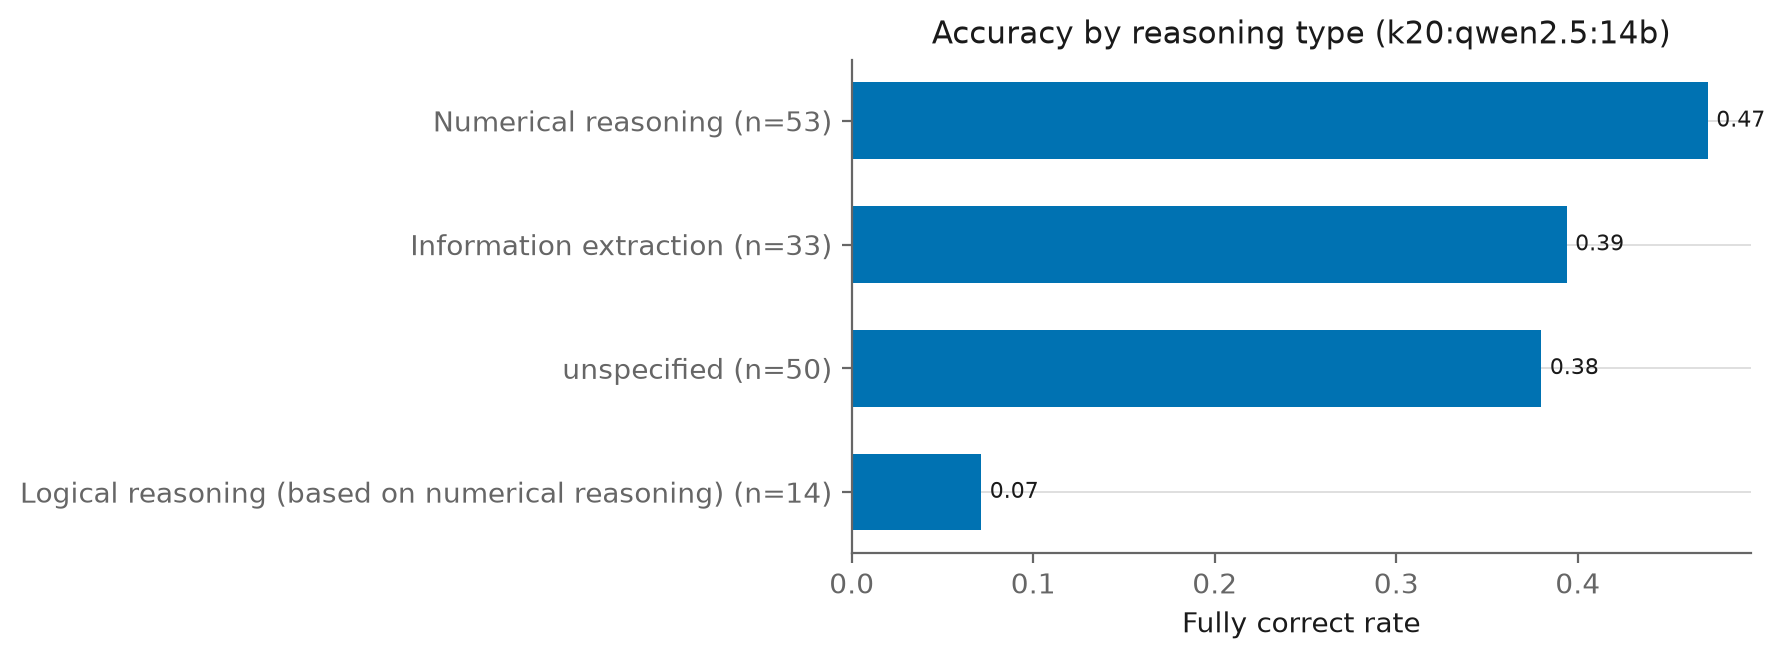

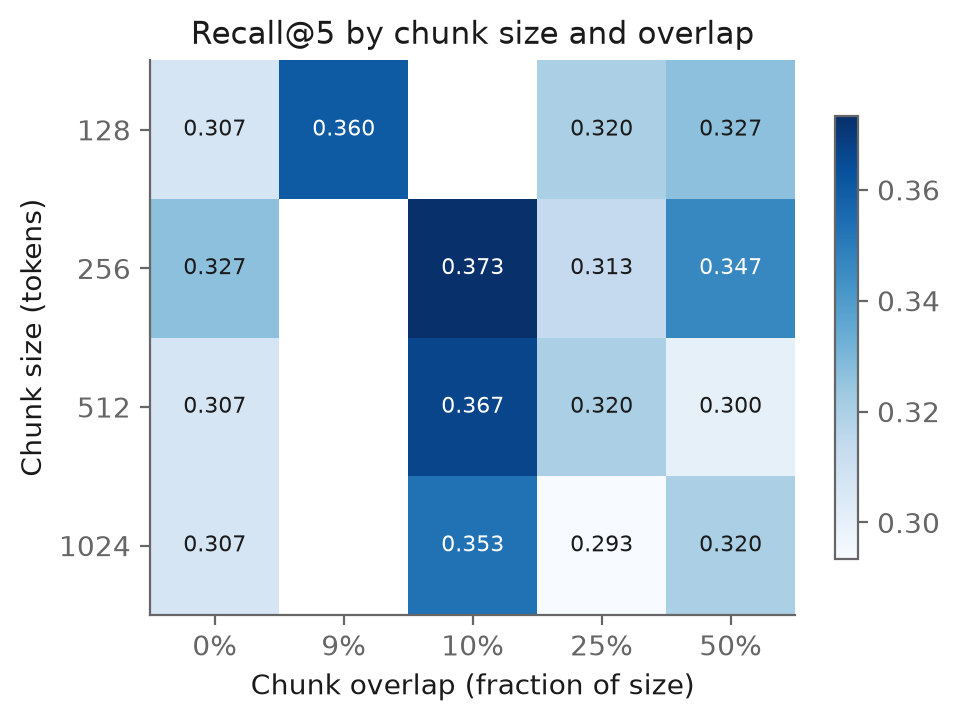

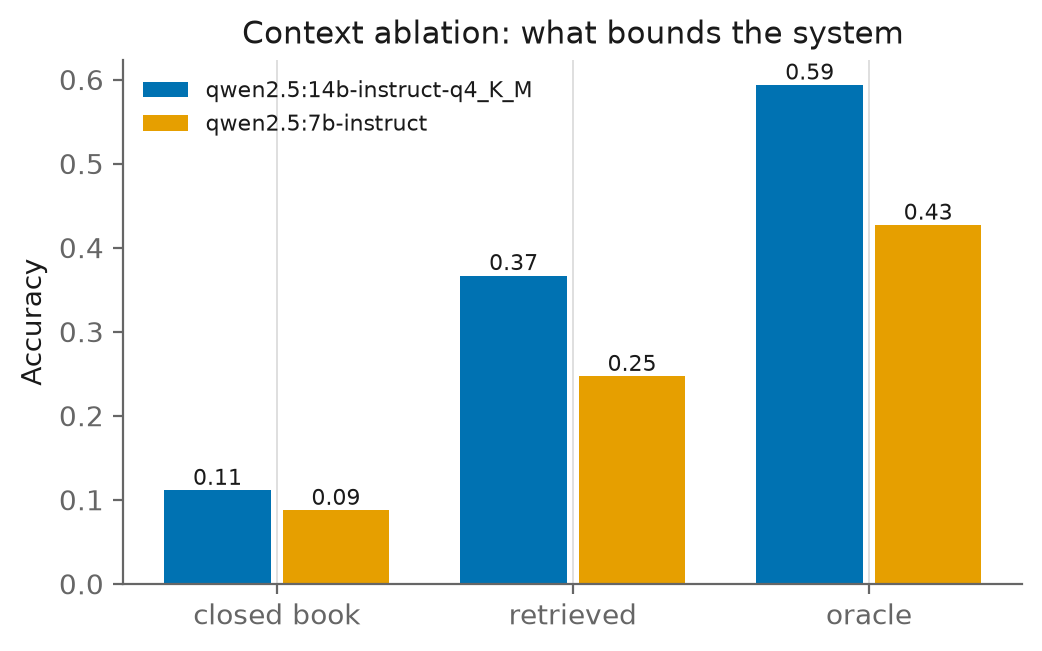

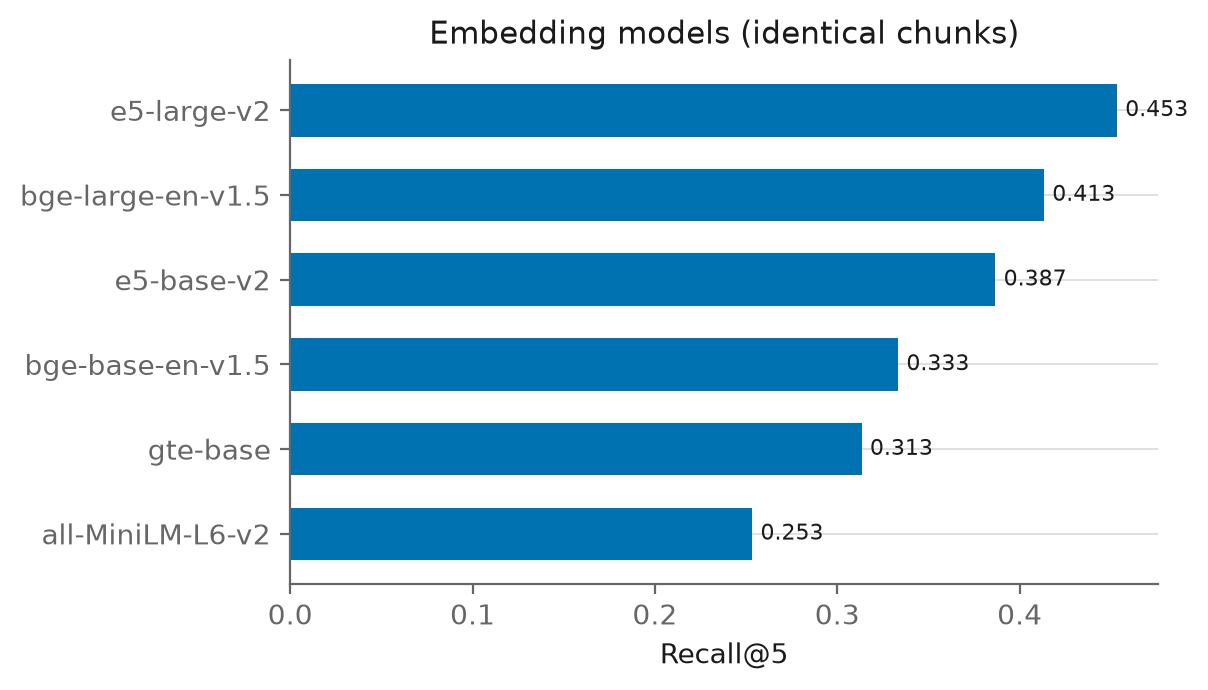

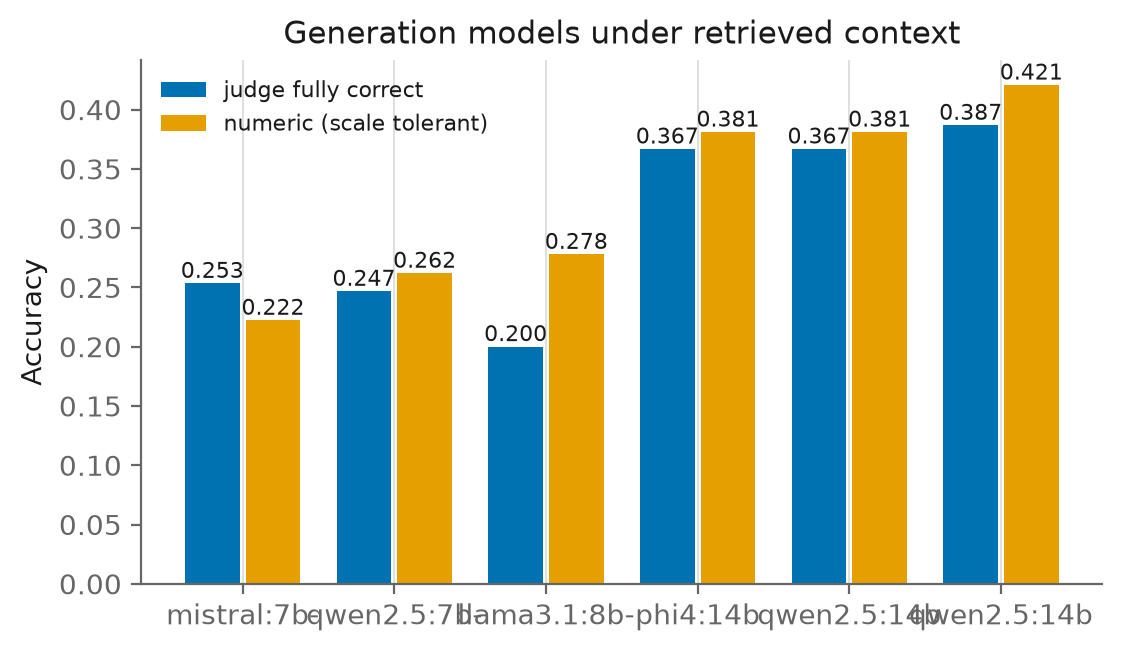

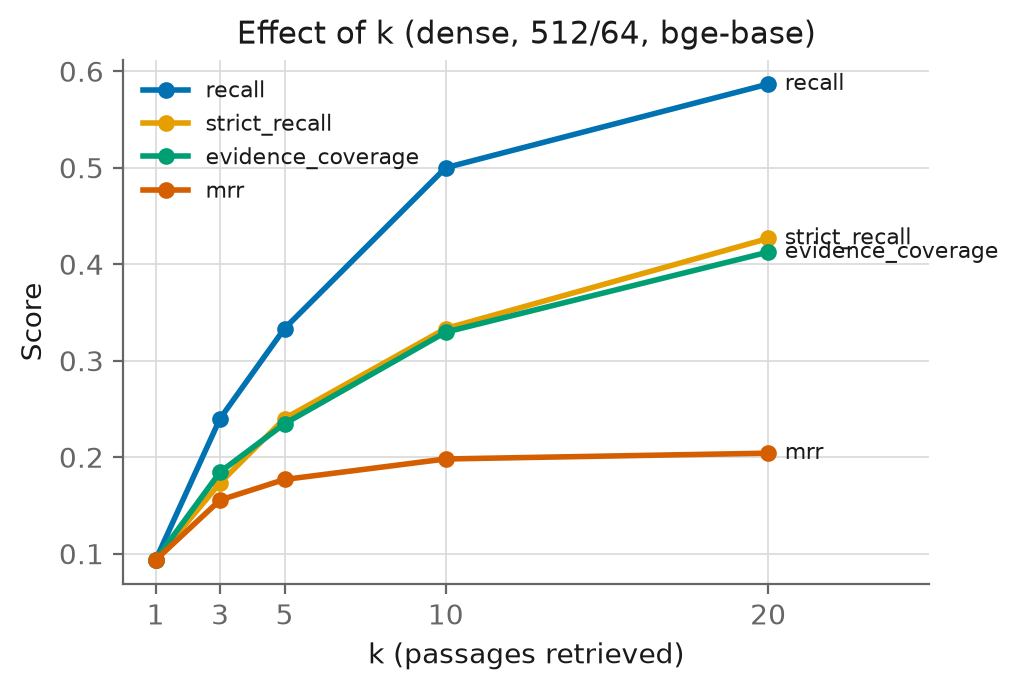

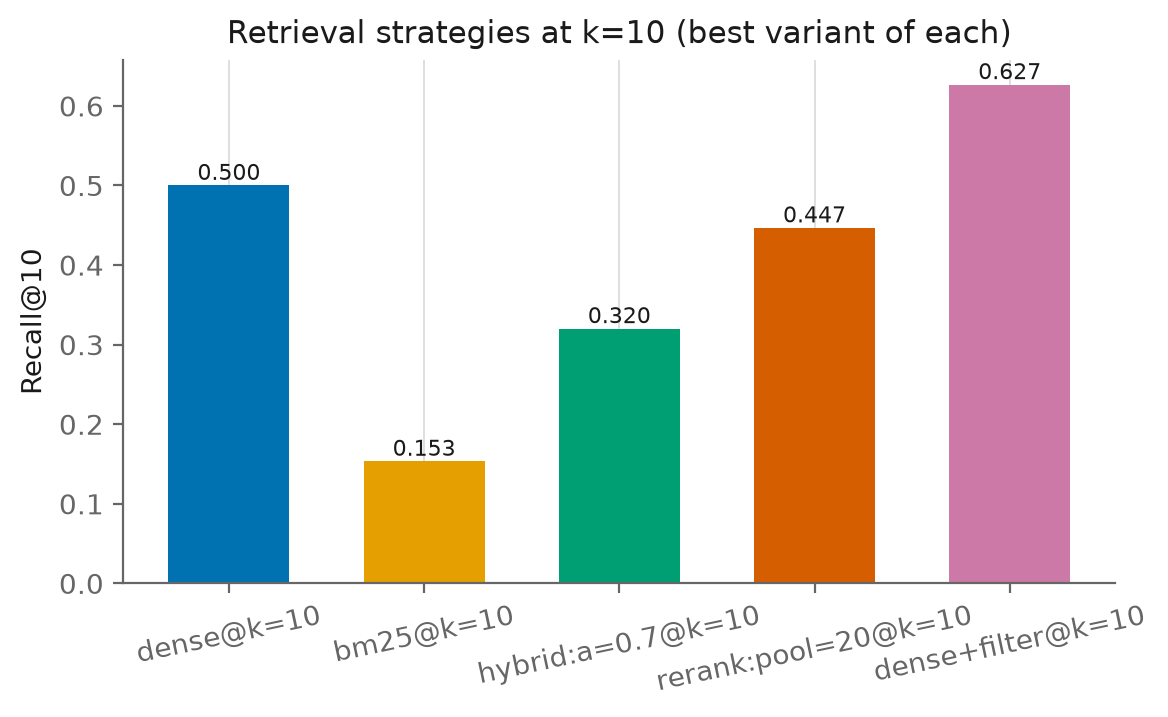

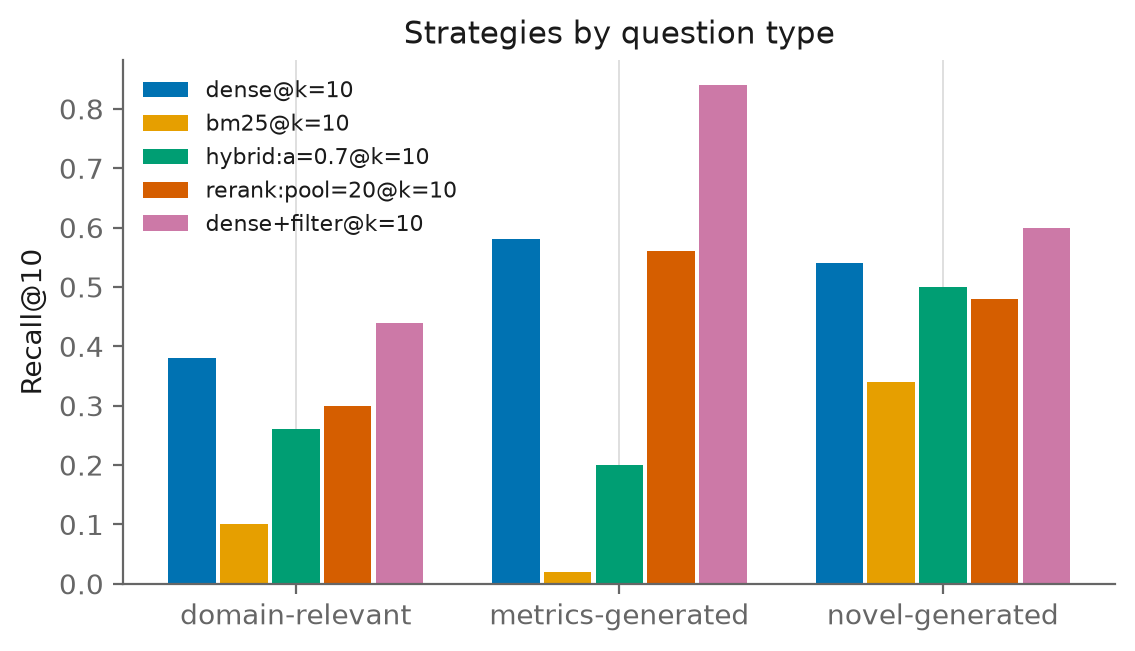

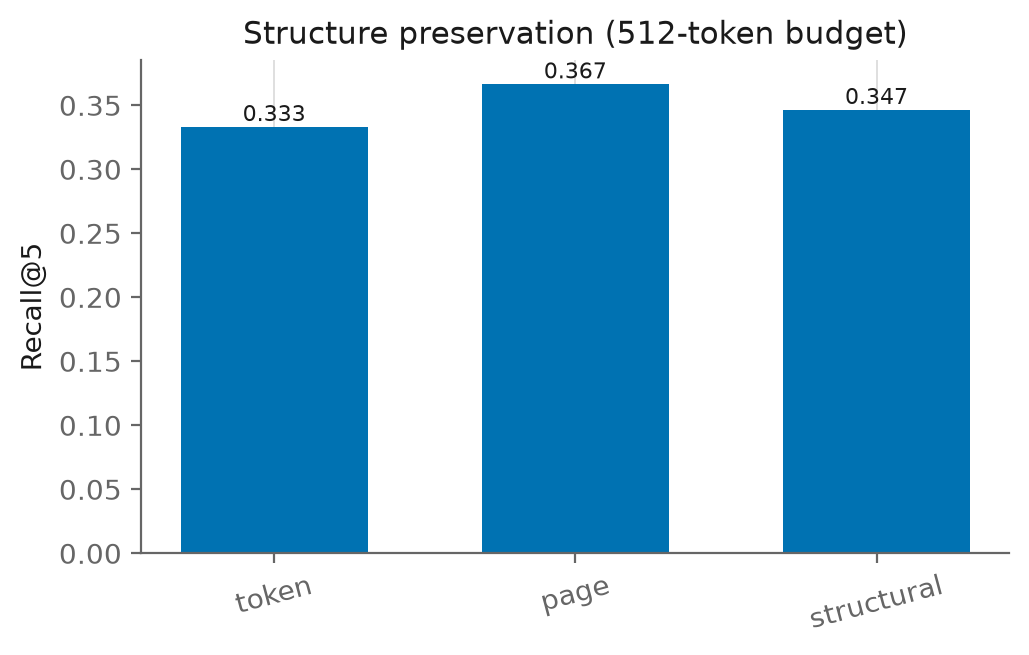

In [10]:
from pathlib import Path
from IPython.display import Image, Markdown, display
for name in ['retrieval_results.md', 'generation_results.md', 'error_analysis.md', 'retrieval_vs_generation.md']:
    p = Path('results/tables') / name
    if p.exists():
        display(Markdown(p.read_text()))
for p in sorted(Path('results/figures').glob('*.png')):
    display(Image(str(p)))